### This model was built for Powei Microfinance Bank, after a recent mass churn of customers to see if more customers are likely to churn.

In [2]:
#Importation of the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import plot_tree
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv('bank_customer_churn.csv')

In [4]:
df

,CustomerID,Age,Gender,Tenure_Months,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complains,Satisfaction_Score,Churn
0,CUST00001,52.0,Male,67.0,55032.0,1.0,1.0,0.0,47462.0,0.0,4.0,0
1,CUST00002,NaN,Female,46.0,51902.0,2.0,0.0,1.0,137924.0,0.0,3.0,0
2,CUST00003,38.0,Female,30.0,106468.0,1.0,0.0,0.0,79385.0,0.0,5.0,0
3,CUST00004,NaN,Female,31.0,46640.0,1.0,1.0,1.0,67781.0,0.0,4.0,0
4,CUST00005,45.0,Male,31.0,137052.0,1.0,1.0,1.0,122601.0,0.0,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...
495,CUST00496,24.0,Female,NaN,71841.0,1.0,1.0,0.0,137288.0,0.0,3.0,0
496,CUST00497,26.0,Female,85.0,55620.0,2.0,1.0,0.0,132202.0,0.0,5.0,0
497,CUST00498,37.0,Female,60.0,101396.0,1.0,1.0,0.0,108634.0,0.0,3.0,0
498,CUST00499,39.0,Male,51.0,79169.0,1.0,1.0,0.0,176583.0,0.0,5.0,0


### Running my EDA.

### Handling my missing data

In [5]:
df['Gender'] = df['Gender'].astype(str).replace('nan', np.nan)
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])



In [6]:
# This should return 0 if it worked
print(df['Gender'].isnull().sum())

0


In [7]:
df['Tenure_Months'] = df['Tenure_Months'].fillna(df['Tenure_Months'].mean())

In [8]:
df['Satisfaction_Score'] = df['Satisfaction_Score'].fillna(df['Satisfaction_Score'].mean())

In [9]:
df['EstimatedSalary'] = df['EstimatedSalary'].fillna(df['EstimatedSalary'].mean())

In [10]:
df['Balance'] = df['Balance'].fillna(df['Balance'].mean())

In [11]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [12]:
df['NumOfProducts'] = df['NumOfProducts'].fillna(df['NumOfProducts'].mean())

In [13]:
binary_cols = ['Complains', 'HasCrCard', 'IsActiveMember']
for col in binary_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          500 non-null    str    
 1   Age                 500 non-null    float64
 2   Gender              500 non-null    str    
 3   Tenure_Months       500 non-null    float64
 4   Balance             500 non-null    float64
 5   NumOfProducts       500 non-null    float64
 6   HasCrCard           500 non-null    float64
 7   IsActiveMember      500 non-null    float64
 8   EstimatedSalary     500 non-null    float64
 9   Complains           500 non-null    float64
 10  Satisfaction_Score  500 non-null    float64
 11  Churn               500 non-null    int64  
dtypes: float64(9), int64(1), str(2)
memory usage: 47.0 KB


### Correlation

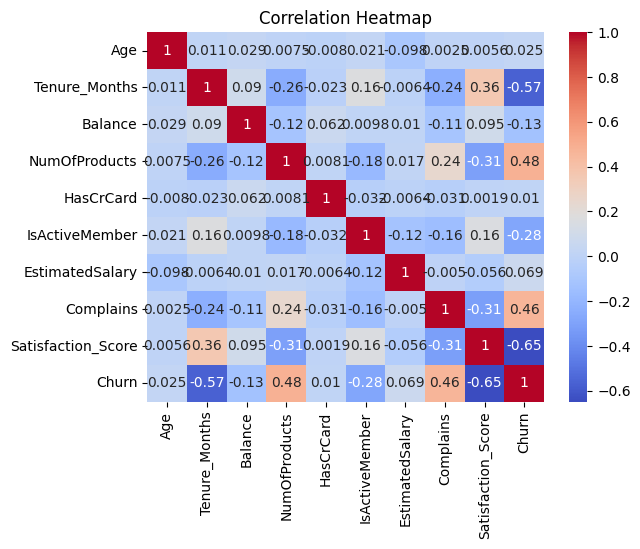

In [15]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [16]:
df.describe()

,Age,Tenure_Months,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complains,Satisfaction_Score,Churn
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,38.158120,44.863931,71983.431330,1.522293,0.712000,0.586000,107902.893246,0.270000,3.525424,0.250000
std,9.012828,25.328955,45094.852425,0.795171,0.453285,0.493042,41174.021882,0.444404,1.064733,0.433446
min,18.000000,1.000000,53.000000,1.000000,0.000000,0.000000,31782.000000,0.000000,1.000000,0.000000
25%,31.000000,24.000000,34729.500000,1.000000,0.000000,0.000000,76140.000000,0.000000,3.000000,0.000000
50%,38.158120,44.000000,69736.500000,1.000000,1.000000,1.000000,107902.893246,0.000000,3.525424,0.000000
75%,45.000000,65.000000,103280.000000,2.000000,1.000000,1.000000,143412.000000,1.000000,4.000000,0.250000
max,57.000000,95.000000,197316.000000,4.000000,1.000000,1.000000,179621.000000,1.000000,5.000000,1.000000


In [17]:
#Complaining members who are active = 58
mask = df ['Complains'] == 1
print(mask)
df.loc[mask, 'IsActiveMember'].value_counts()

0      False
1      False
2      False
3      False
4      False
       ...  
495    False
496    False
497    False
498    False
499    False
Name: Complains, Length: 500, dtype: bool


IsActiveMember
0.0    73
1.0    62
Name: count, dtype: int64

In [18]:
#Complaining members who churned
df.loc[mask, 'Churn'].value_counts()

Churn
1    78
0    57
Name: count, dtype: int64

<Axes: >

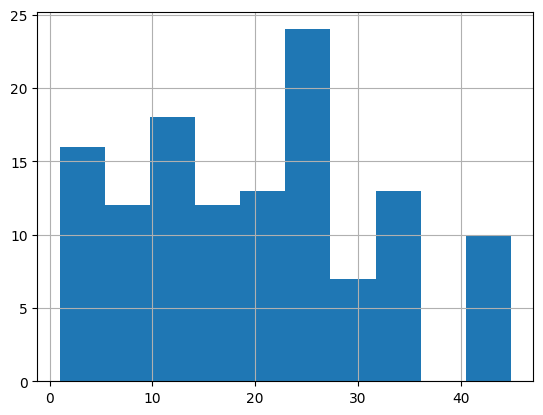

In [19]:
#Churning occurs when 
com = df['Churn'] == 1
df.loc[com, 'Tenure_Months'].hist()

### Checking the average of my selected features

In [36]:
# Replace all four cells with this single block:
churners = df[df['Churn'] == 1]

print('The average tenure months of churners is', churners['Tenure_Months'].mean())
print('The average balance of churners is', churners['Balance'].mean())
print('The average Satisfaction_Score of churners is', churners['Satisfaction_Score'].mean())
print('The average NumOfProducts owned by churners is', churners['NumOfProducts'].mean())

The average tenure months of churners is 20.045114470842332
The average balance of churners is 61839.15921030043
The average Satisfaction_Score of churners is 2.3292203389830513
The average NumOfProducts owned by churners is 2.181248407643312


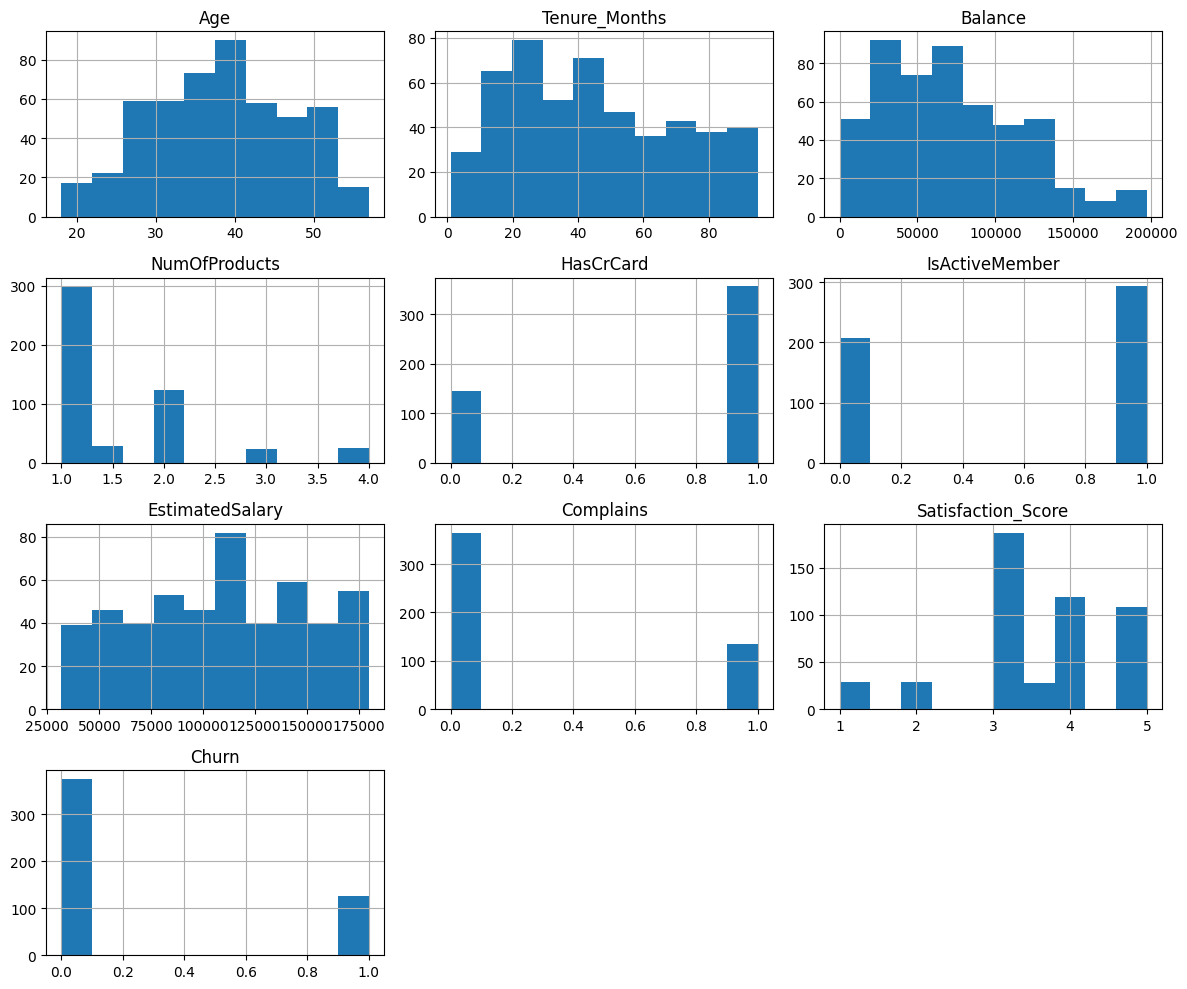

In [21]:
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

### Kernel Density Estimation (KDE)

A KDE plot is a smoothed distribution curve that shows how values are spread across 
a feature. Each plot is split by Churn (0 = Staying, 1 = Churning), making it easy 
to spot where churners and non-churners differ. A clear separation between the two 
curves signals a strong predictor — as seen with Tenure_Months, where churners 
cluster heavily at shorter tenures.

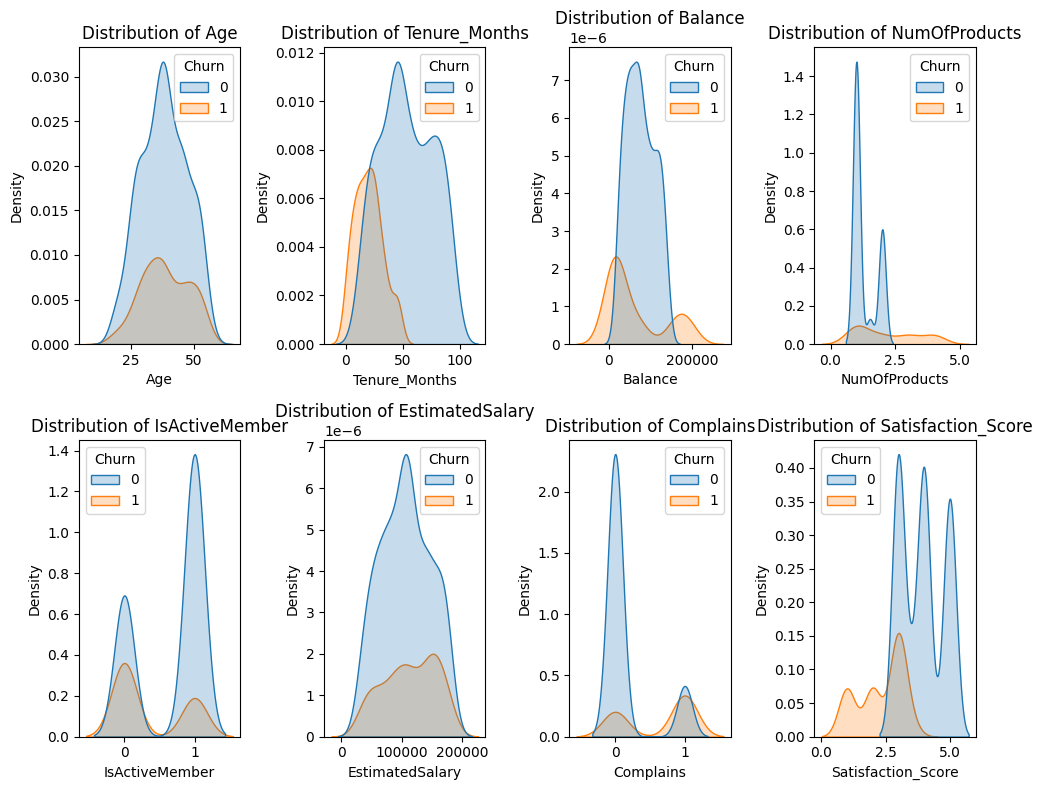

In [22]:
#Kernel Density Estimation (KDE)
# 1. Define your columns using names (safer than index numbers)
cols_to_plot = ['Age', 'Tenure_Months', 'Balance', 'NumOfProducts', 
                'IsActiveMember', 'EstimatedSalary', 'Complains', 'Satisfaction_Score']

# 2. Set up a grid of plots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 4, figsize=(10, 8))
axes = axes.flatten()  # Flatten the 2D array of axes to a 1D list

# 3. Loop through columns and plot each one
for i, col in enumerate(cols_to_plot):
    sns.kdeplot(data=df, x=col, hue='Churn', ax=axes[i], fill=True)
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()


### Taking care of categorical data

In [23]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

### Choosing my features and assigning them to variables of x and y

In [24]:
x = df[['Age', 'Tenure_Months', 'Balance',	'NumOfProducts', 'IsActiveMember',	'EstimatedSalary', 'Complains', 'Satisfaction_Score']].values
y = df['Churn'].values
print(x)
print(y)

[[5.20000000e+01 6.70000000e+01 5.50320000e+04 ... 4.74620000e+04
  0.00000000e+00 4.00000000e+00]
 [3.81581197e+01 4.60000000e+01 5.19020000e+04 ... 1.37924000e+05
  0.00000000e+00 3.00000000e+00]
 [3.80000000e+01 3.00000000e+01 1.06468000e+05 ... 7.93850000e+04
  0.00000000e+00 5.00000000e+00]
 ...
 [3.70000000e+01 6.00000000e+01 1.01396000e+05 ... 1.08634000e+05
  0.00000000e+00 3.00000000e+00]
 [3.90000000e+01 5.10000000e+01 7.91690000e+04 ... 1.76583000e+05
  0.00000000e+00 5.00000000e+00]
 [4.40000000e+01 7.60000000e+01 8.49240000e+04 ... 1.07902893e+05
  0.00000000e+00 3.00000000e+00]]
[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0
 0 0 0 1 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 1 1 0 0 0 1 0
 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 0
 0 0 0 0 1 1 0 0 1 0 1 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 1 1 1 0 1 1 0 0 0 0 1
 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 1 1 0 0 0 1 0 0 0
 0 1 0 0 0 0 0 0 0 0 1 1 

### Splitting my dataset

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=24, stratify=y)

### Creating my model

In [26]:
Powei = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=24)
Powei.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Evaluating my model

In [27]:
y_pred = Powei.predict(x_test)

In [28]:
#Prediction probability scores. 
# Threshold = > 0.5, likely to churn
Powei.predict_proba(x_test)[:,1]

array([0.01, 0.47, 0.  , 1.  , 0.96, 0.  , 0.  , 0.  , 0.66, 0.02, 0.05,
       0.85, 0.02, 0.79, 0.  , 0.71, 0.  , 0.01, 0.  , 0.01, 0.01, 0.46,
       0.59, 0.  , 0.  , 0.02, 0.05, 0.03, 0.09, 0.51, 0.15, 0.01, 0.  ,
       0.35, 0.92, 0.65, 0.52, 0.03, 0.04, 0.02, 0.  , 0.01, 0.  , 0.1 ,
       0.  , 0.08, 0.  , 0.62, 0.52, 0.05, 0.  , 0.  , 0.01, 0.01, 1.  ,
       0.  , 0.17, 0.  , 0.78, 0.97, 0.11, 0.17, 0.  , 0.86, 0.35, 0.75,
       0.24, 0.02, 0.  , 0.06, 0.  , 0.  , 0.01, 0.  , 0.04, 0.34, 0.  ,
       0.  , 0.01, 0.  , 0.44, 1.  , 0.01, 0.  , 0.08, 0.01, 0.  , 0.  ,
       0.01, 0.  , 0.86, 0.71, 0.  , 0.97, 0.93, 0.01, 0.  , 0.05, 0.32,
       0.15])

### Confusion Matrix

In [29]:

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        75
           1       1.00      0.92      0.96        25

    accuracy                           0.98       100
   macro avg       0.99      0.96      0.97       100
weighted avg       0.98      0.98      0.98       100

Accuracy: 0.98
Confusion Matrix:
 [[75  0]
 [ 2 23]]


### Feature importance

In [30]:
features = ['Age', 'Tenure_Months', 'Balance',	'NumOfProducts', 'IsActiveMember',	'EstimatedSalary', 'Complains', 'Satisfaction_Score']
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': Powei.feature_importances_
}).sort_values('Importance', ascending=False)
print(importance_df)

              Feature  Importance
1       Tenure_Months    0.280627
7  Satisfaction_Score    0.255485
2             Balance    0.209898
3       NumOfProducts    0.087233
6           Complains    0.061145
5     EstimatedSalary    0.050490
0                 Age    0.034432
4      IsActiveMember    0.020690


### Visualizing my first tree

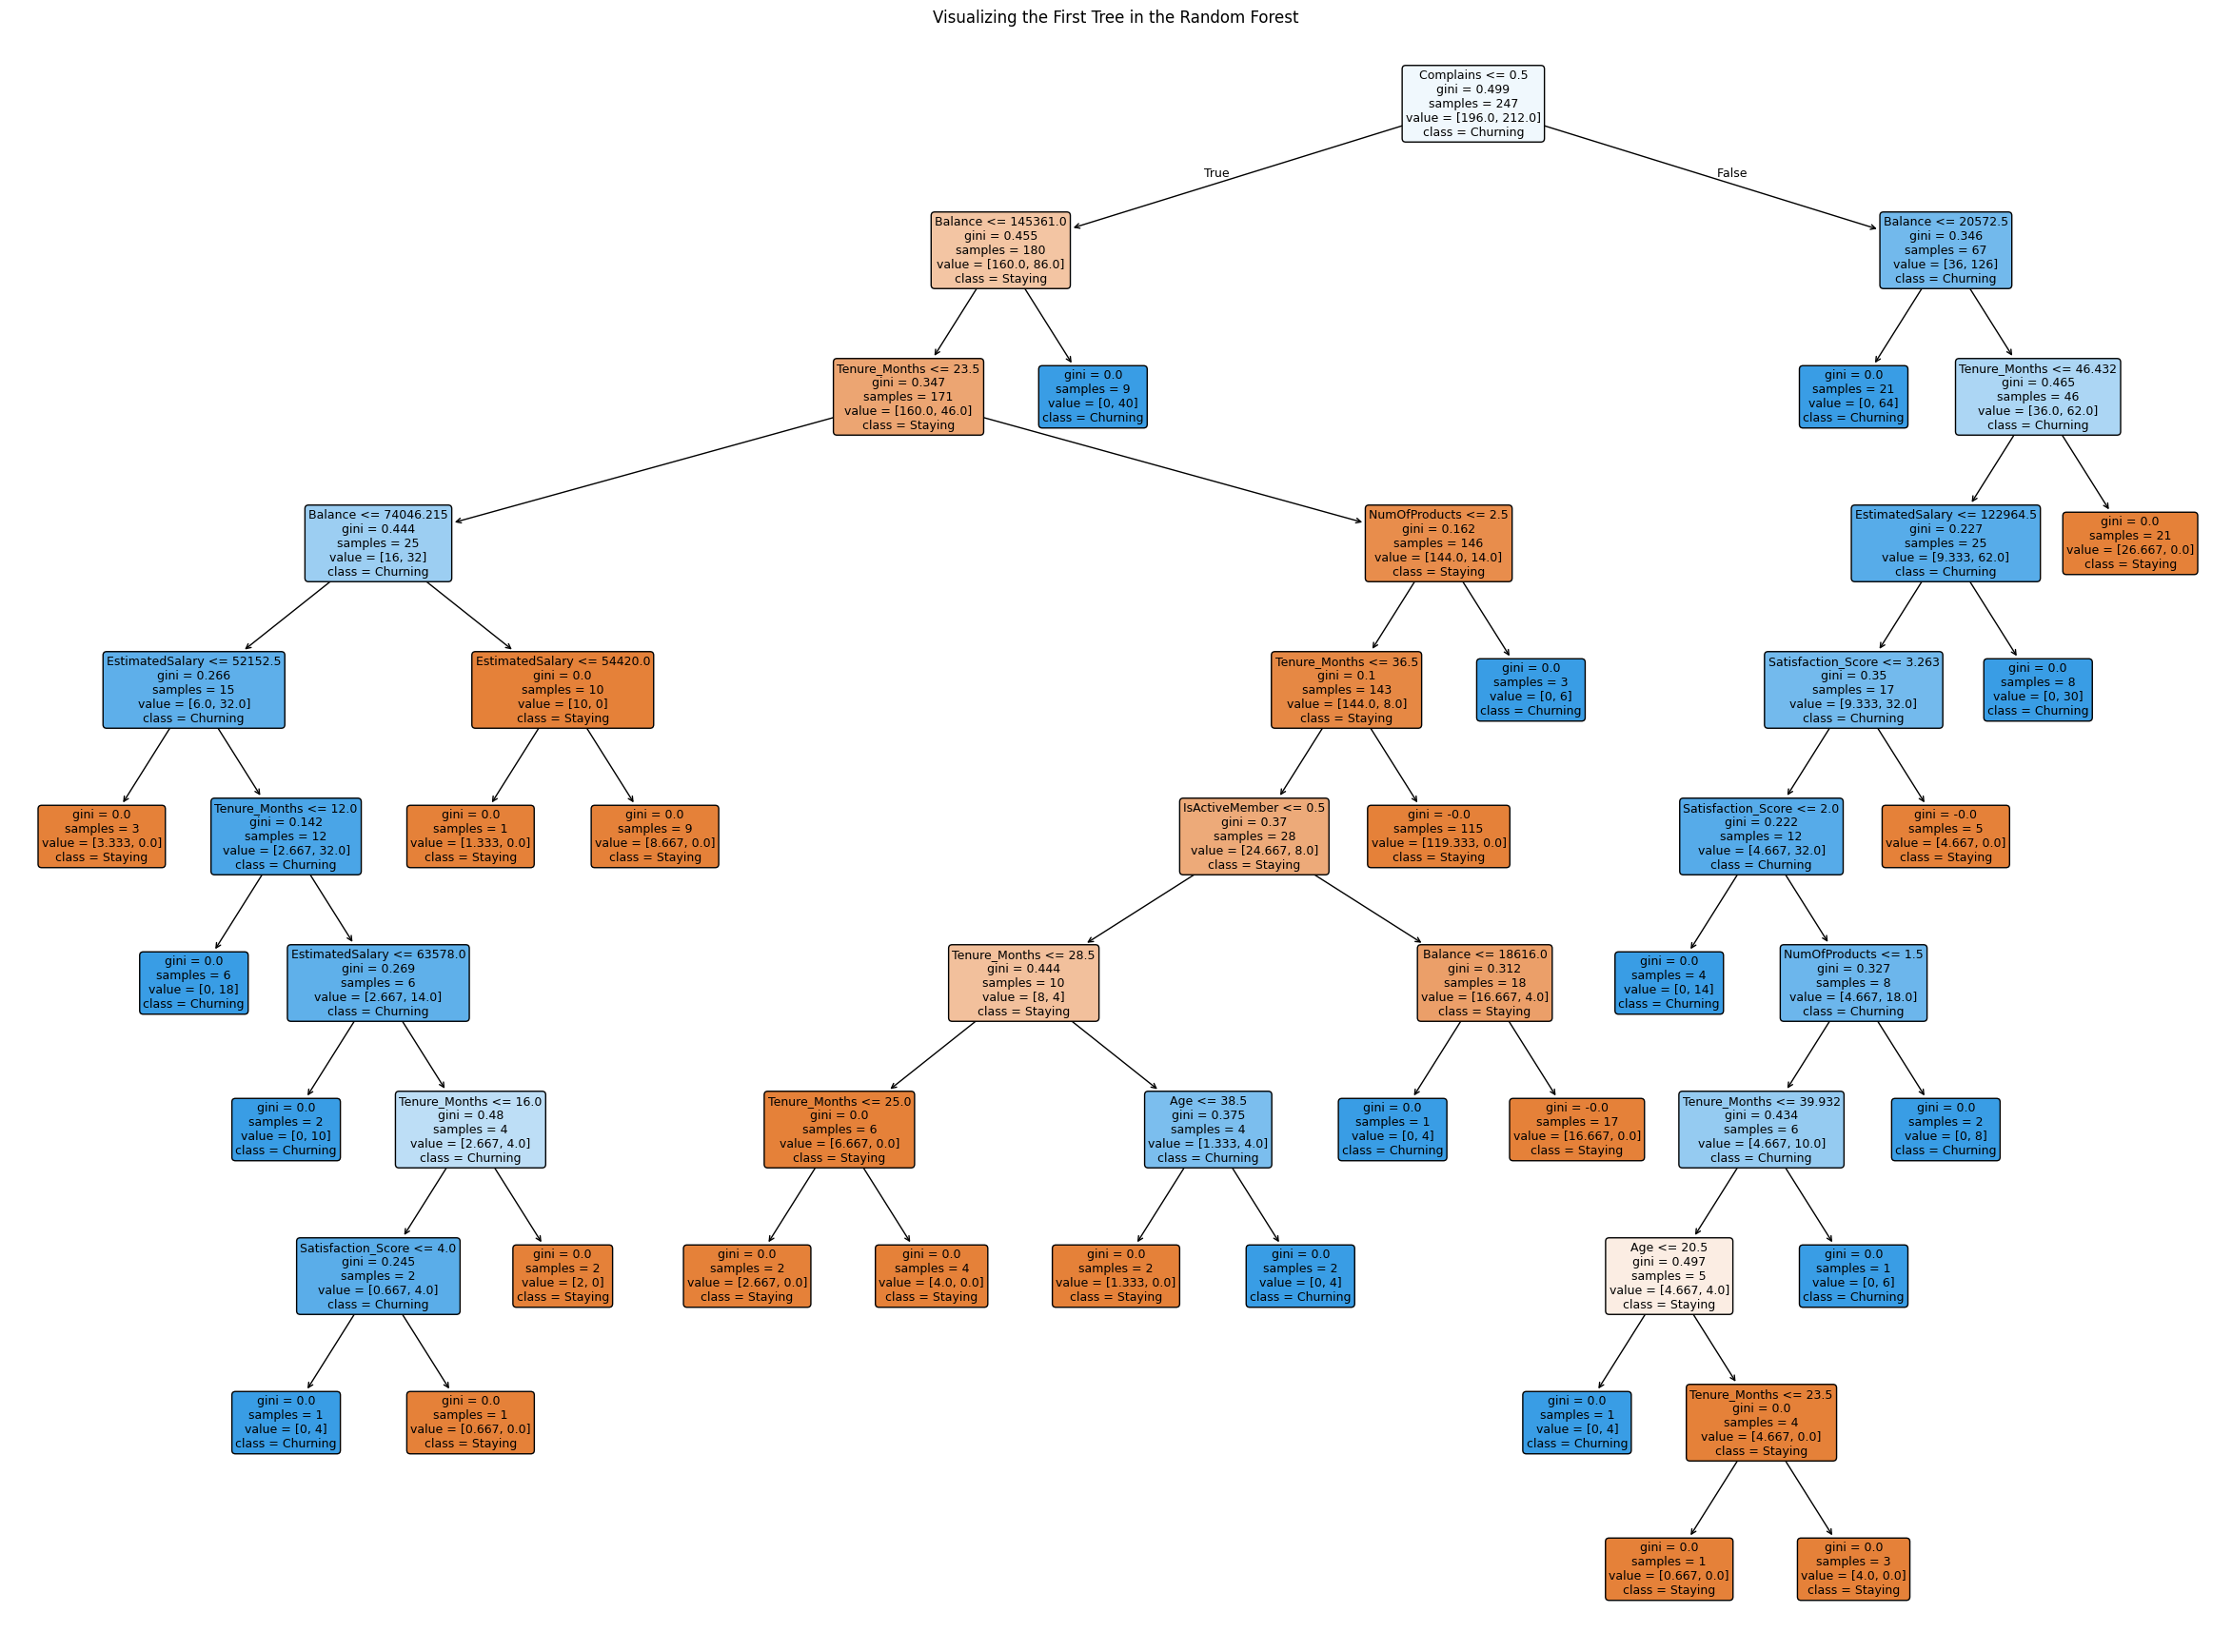

In [31]:
features = ['Age', 'Tenure_Months', 'Balance',	'NumOfProducts', 'IsActiveMember',	'EstimatedSalary', 'Complains', 'Satisfaction_Score']
tree_to_plot = Powei.estimators_[0]
plt.figure(figsize=(30,22))
plot_tree(tree_to_plot,
          feature_names=features,
          class_names=['Staying', 'Churning'],
          filled=True,
          rounded=True,
          fontsize=9)
plt.title("Visualizing the First Tree in the Random Forest")
plt.savefig('Powei_Microfinance_Bank.png')
plt.show()

In [32]:
#Clustering
# Use the same features
x_cluster = df[['Age', 'EstimatedSalary', 'Tenure_Months', 'Balance', 'Satisfaction_Score', 'NumOfProducts', 'Complains', 'IsActiveMember']]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_cluster)

# Find best K
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(x_scaled)
    print(f"k={k}, silhouette={silhouette_score(x_scaled, labels):.4f}")

k=2, silhouette=0.2457
k=3, silhouette=0.1663
k=4, silhouette=0.1718
k=5, silhouette=0.1422
k=6, silhouette=0.1472
k=7, silhouette=0.1480


In [33]:
km_final = KMeans(n_clusters=2, random_state=42, n_init=10)
df['Segment'] = km_final.fit_predict(x_scaled)

In [34]:
print(pd.crosstab(df['Segment'], df['Churn'], normalize='index').round(2))

Churn       0     1
Segment            
0        0.94  0.06
1        0.12  0.88


In [35]:
#Grouping by our three most important features
df.groupby('Segment').mean(numeric_only=True).round(1)

,Age,Gender,Tenure_Months,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complains,Satisfaction_Score,Churn
Segment,,,,,,,,,,,
0,38.4,0.4,52.4,77849.1,1.3,0.7,0.7,107113.9,0.1,3.9,0.1
1,37.4,0.5,19.4,52122.6,2.3,0.7,0.3,110574.3,0.8,2.4,0.9


### Report Documentation — Powei Microfinance Bank Customer Churn Analysis

Introduction

Following a recent mass churn event, Powei Microfinance Bank commissioned this analysis to identify customers likely to churn and understand the behavioural patterns driving attrition. A Random Forest classification model and K-Means clustering were applied to a dataset of 500 customers.

After carrying out my EDA, I discovered missing data across several columns and addressed them appropriately. Categorical column like Gender was filled using mode imputation, continuous columns like Tenure_Months, Balance, Age, and EstimatedSalary were filled with their column means, while binary columns (Complains, HasCrCard, IsActiveMember) were filled using mode imputation to preserve their 0/1 integrity.

From the correlation heatmap, features such as Gender and HasCrCard showed near-zero correlation with the target variable Churn and were excluded from the model entirely. Age and EstimatedSalary also showed low correlation, but their variance levels (meaning their values were spread across a wide range) made a case for inclusion — and this proved worthwhile, as both contributed meaningfully to the model with importance scores of 0.034 and 0.050 respectively. Balance similarly showed low correlation but was retained for the same reason, and emerged as the third most important feature with an importance score of 0.21.

Feature Importance List

| Feature            | Importance |
|--------------------|------------|
| Tenure_Months      | 0.281      |
| Satisfaction_Score | 0.255      |
| Balance            | 0.210      |
| NumOfProducts      | 0.087      |
| Complains          | 0.061      |
| EstimatedSalary    | 0.050      |
| Age                | 0.034      |
| IsActiveMember     | 0.021      |

Tenure_Months, Satisfaction_Score, and Balance are clearly the dominant predictors of churn, collectively accounting for over 74% of the model's decision-making weight. These three features should be the primary focus of any future retention strategy.

Model Performance

The model was tested on 100 customers it had never seen before. Out of those 100, it correctly identified 98, giving it an accuracy of 98%. Of the 25 customers who actually churned in the test set, the model successfully flagged 23 of them as likely to leave. Only 2 churners slipped through undetected. More importantly, every customer the model flagged as a churner truly was one, there were zero false alarms.

In business terms, this means the bank can act on the model's warnings with confidence. If the model flags a customer as at-risk, that customer almost certainly is at-risk. The only cost is that roughly 1 in 12 churners may go undetected, a small and acceptable tradeoff given the model's overall reliability.

Customer Segmentation

K-Means clustering (K=2, selected based on the highest silhouette score of 0.2457) revealed
two distinct customer groups:

| Segment | Churn Rate | Avg. Tenure | Avg. Balance | Complains	| Satisfaction Score |
|---------|------------|-------------|--------------|-----------|--------------------|
| 0 — Stable   | 6%  | ~52 months  | ~₦77,849 | 0.1 | 3.9 |
| 1 — At-Risk  | 88% | ~19 months  | ~₦52,123 | 0.8	| 2.4 |

Segment 1 is the critical intervention target. Customers in this group are characterised by short tenure, low balances, higher rate of complaints, and low satisfaction scores (a profile that strongly predicts churn). The complaints pattern is particularly telling: unresolved issues early in a customer's lifecycle compound dissatisfaction and accelerate the decision to leave.

Early engagement within the first 20 months, combined with active satisfaction monitoring and a fast-response complaints resolution process, represents the most actionable path to reducing attrition at Powei Microfinance Bank.

### Recommendations

1. Intervene early: implement structured check-ins within the first 20 months of every customer's lifecycle, as this is when churn risk is highest.

2. Resolve complaints fast: an unresolved complaint from a Segment 1 customer is a near-certain churn signal. Target 24–48 hour resolution for at-risk customers.

3. Monitor satisfaction actively: any customer scoring below 3 should automatically trigger a retention touchpoint.

4. Deploy the model monthly: by using `Powei.predict_proba(x_test)[:,1]` to generate a watchlist of customers above the 0.5 churn threshold for proactive outreach.